In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
# pd.set_option('display.max_rows', None)
from src.data_preprocessing import DataPreprocessor
from src.data_exploration import DataExplorator
from src.model_train import ModelTrainer
from src.model_evaluate import ModelEvaluator

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
preprocessing = DataPreprocessor(pd.read_excel('/home/ester/Documents/Gitlab/Case_Shape/FPSO-Failure-Prediction/data/O_G_Equipment_Data.xlsx'))
df_transformed, categorical_cols, numerical_cols = preprocessing.transform()

In [3]:
df_transformed.head()

,preset_1,preset_2,temperature,pressure,vibrationx,vibrationy,vibrationz,frequency,fail,fail_continued,fail_next,preset_combined
cycle,,,,,,,,,,,,
1,3,6,44.235188,47.657253,46.441769,64.820328,66.454521,44.483250,False,False,False,3_6
2,2,4,60.807236,63.172077,62.005951,80.714432,81.246407,60.228715,False,False,False,2_4
3,2,1,79.027534,83.032188,82.642113,98.254387,98.785194,80.993479,False,False,False,2_1
4,2,3,79.716240,100.508636,122.362320,121.363426,118.652534,80.315567,False,False,False,2_3
5,2,5,39.989056,51.764832,42.514301,61.037910,50.716469,64.245166,False,False,False,2_5


In [4]:
df_transformed.info(1)

<class 'pandas.core.frame.DataFrame'>
Index: 800 entries, 1 to 800
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   preset_1         800 non-null    category
 1   preset_2         800 non-null    category
 2   temperature      800 non-null    float32 
 3   pressure         800 non-null    float32 
 4   vibrationx       800 non-null    float32 
 5   vibrationy       800 non-null    float32 
 6   vibrationz       800 non-null    float32 
 7   frequency        800 non-null    float64 
 8   fail             800 non-null    category
 9   fail_continued   800 non-null    category
 10  fail_next        799 non-null    category
 11  preset_combined  800 non-null    category
dtypes: category(6), float32(5), float64(1)
memory usage: 34.3 KB


In [5]:
categorical_cols = ['preset_1', 'preset_2']  
numerical_cols = ['temperature','pressure','vibrationx','vibrationy', 'vibrationz']   
target = 'fail'

In [6]:
data_explorator = DataExplorator()

1 - Calculate how many times the equipment has failed.  
  
During the FPSO’s operation, various factors can cause the machine to fail and prolong its failure state. We ask you to explore the available data, identify, and calculate the number of times the equipment has failed throughout its operation.  

In [7]:
data_explorator.get_failure_events(df_transformed)

Overall failures: 66
Shift to failures: 10


In [8]:
data_explorator.average_failure_duration_cycles(df_transformed)

Average duration of continuous failure: 6.50 cycles




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



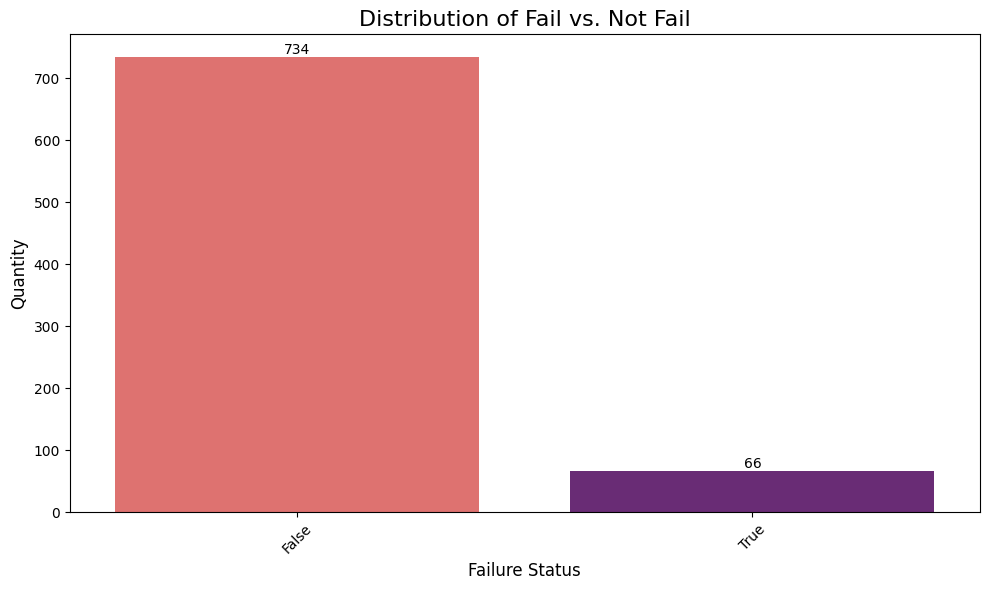

In [9]:
data_explorator.plot_target_balance(df_transformed)

During the equipment’s operation, a total of 66 cycles were recorded in a failure state.  
However, many of these belong to ongoing failure periods, meaning the same failure persisted across multiple cycles. In fact, the average duration of a continuous failure was 6.50 cycles. Based on this, the equipment transitioned into a failure condition 10 times. 

Furthermore, there are 746 non-failure states compared to only 66 failure states. This indicates that we are dealing with an imbalanced classification problem.

2. Categorize equipment failures by setup configurations (Preset 1 and Preset 2).

How do the variables Preset_1 and Preset_2 behave during operation? What insights can we derive from these variables?


In [10]:
# import seaborn as sns

# palette = sns.color_palette('magma')
# hex_codes = palette.as_hex()
# print(hex_codes)



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



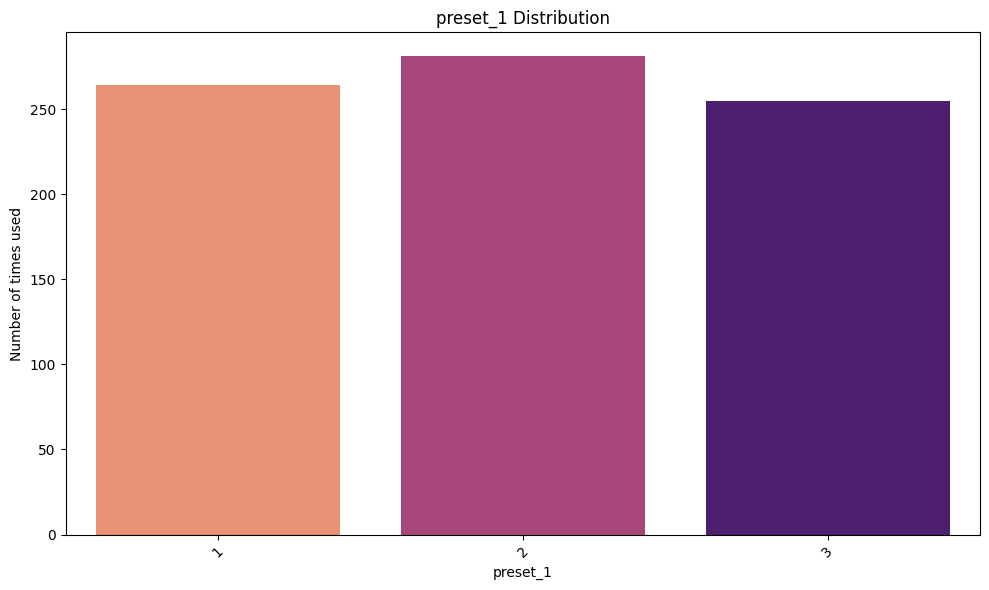



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



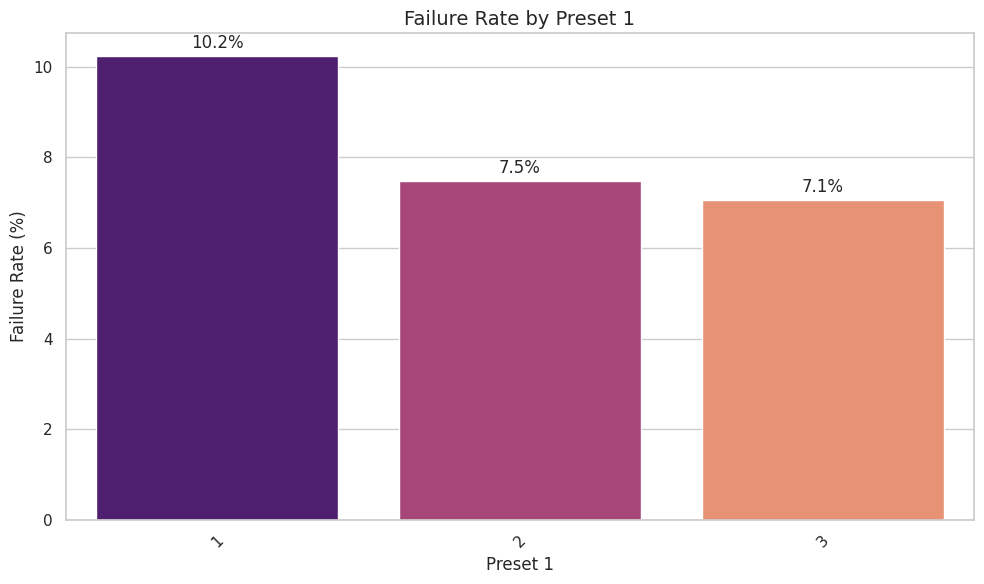



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



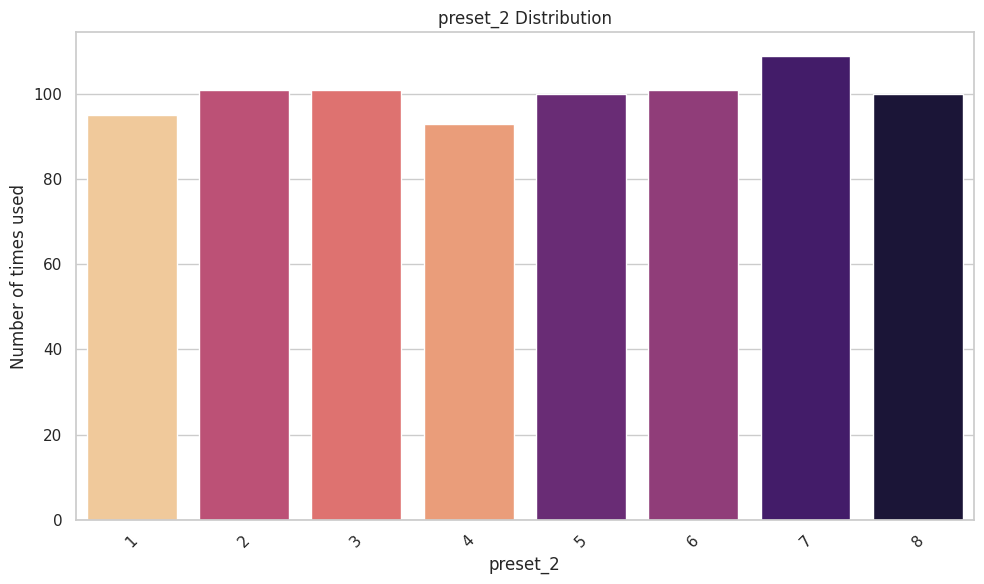



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



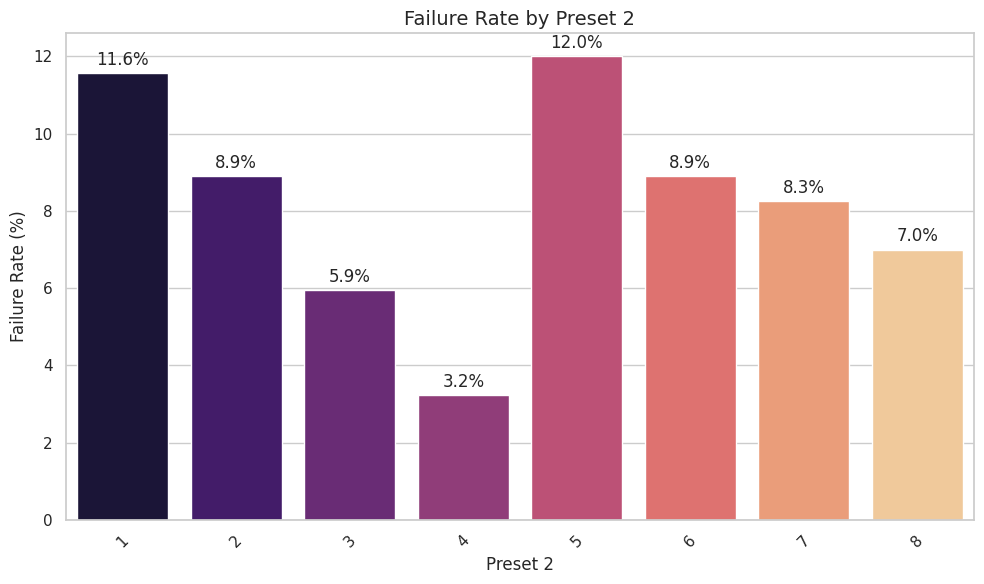



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



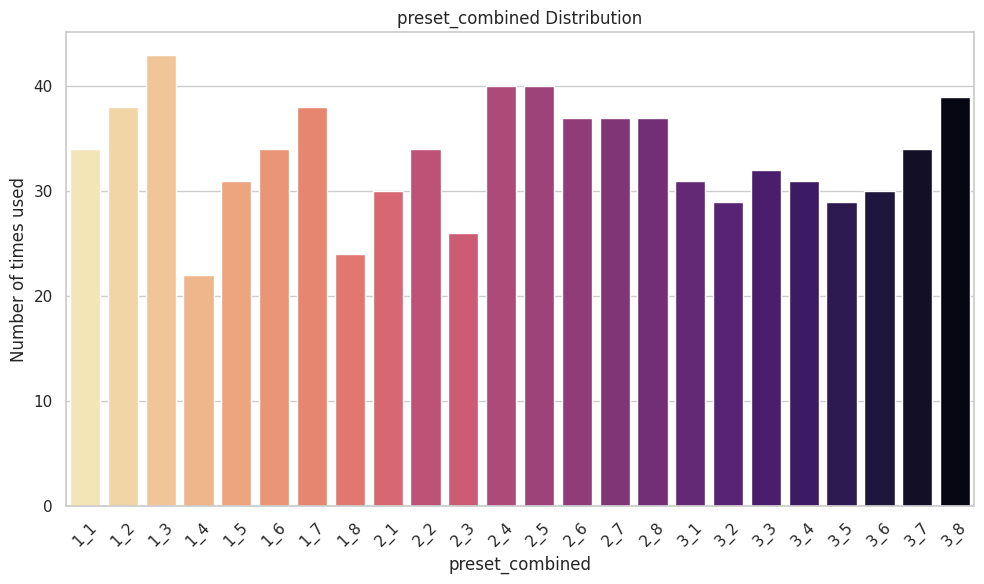



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



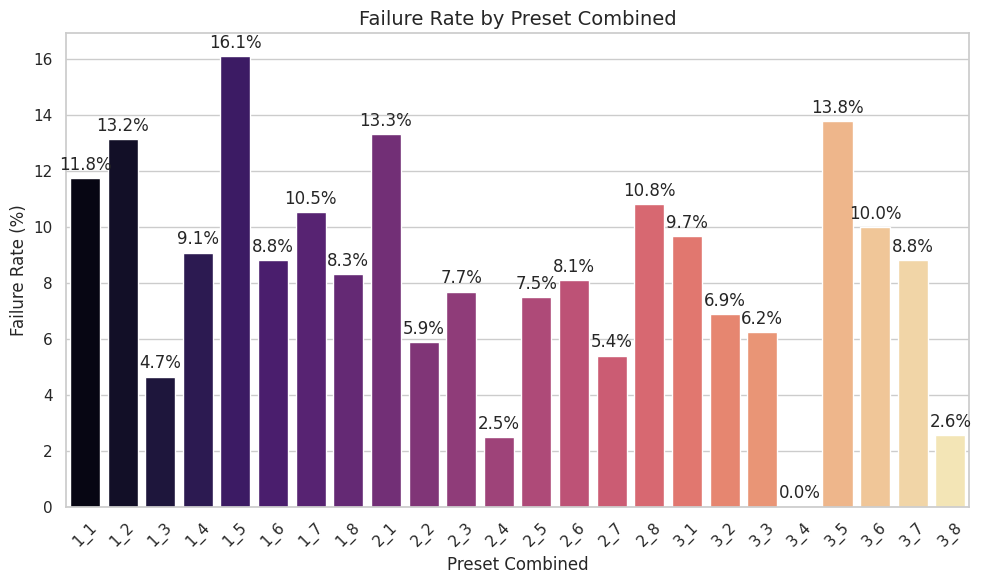

In [11]:
for i in ['preset_1','preset_2','preset_combined']:
    data_explorator.plot_column_distribution(df_transformed,i)
    data_explorator.plot_failure_rate_by_category(df_transformed,i)

In [12]:
data_explorator.get_top_preset_combinations_before_failure(df_transformed)

Most common preset combinations before a failure (in %):
  preset_combined  percentage
0             2_5        40.0
1             2_2        20.0
2             2_7        10.0
3             1_3        10.0
4             1_7        10.0


In [13]:
data_explorator.evaluate_preset_transition_failure_impact(df_transformed, '2_5', '1_5')

Sequence 2_5 → 1_5 → failure occurred 0 times.
This represents 0.0% of all failure events.



We observe that most failures occurred when preset_1 was set to 1 and in preset_2 to either 1 or 5, with the 1_5 (preset_1 + preset_2) combination being the most frequent during failures. Interestingly, the 2_5 combination appears in 40% of the cycles immediately before a failure.

This suggests that preset_2_5 might be contributing to the conditions leading to failure, even though the actual failure tends to occur when the preset has already changed to 1_5. However, when specifically analyzing transitions from 2_5 to 1_5 followed by a failure, we found no such cases.

This may indicate that preset_2_5 alone is not the direct cause of the failure, but rather a potential early warning signal that precedes unstable conditions.


Importantly, preset_2 = 5 continues to appear in failure-related combinations, regardless of the value of preset_1. This makes it the strongest individual indicator of system failure and a potential root cause or contributing factor.

3. Categorize equipment failures by their nature/root cause according to parameter readings (temperature, pressure, and others).

Analyze patterns in these readings that could indicate specific failure types. How do these patterns differ across operational regimes? Provide insights based on your findings.

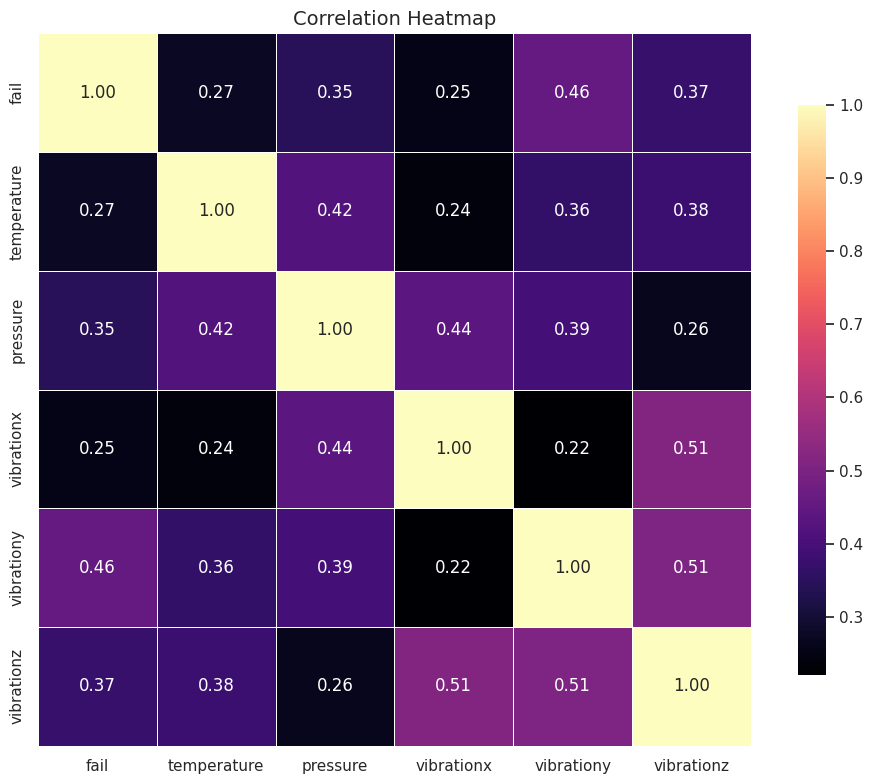

In [14]:
data_explorator.plot_correlation(df_transformed[['fail']+numerical_cols])



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



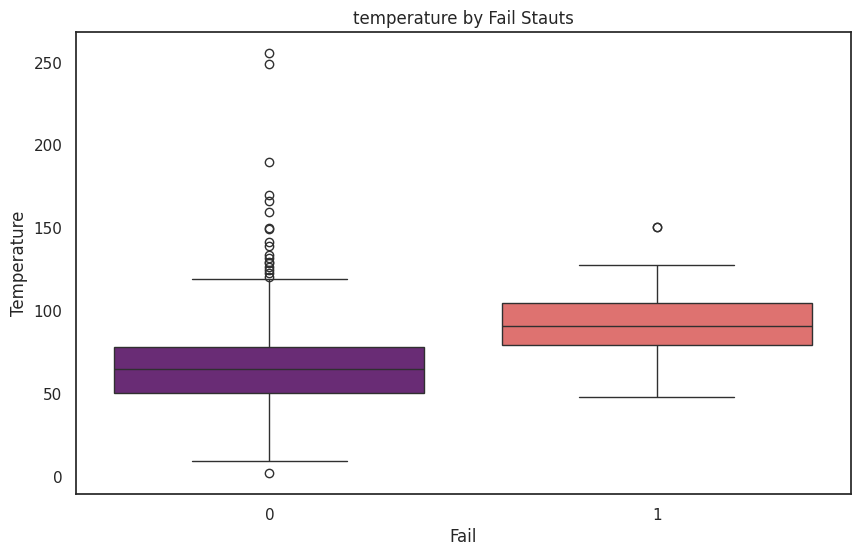



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



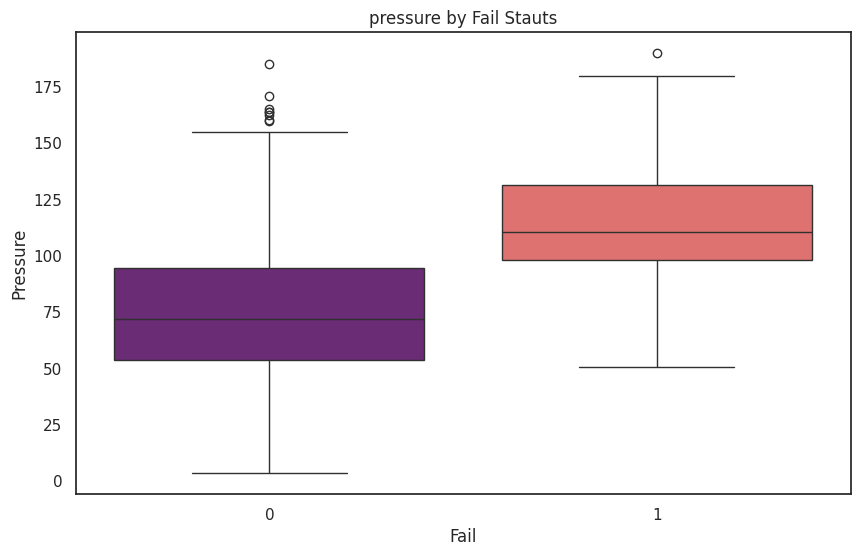



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



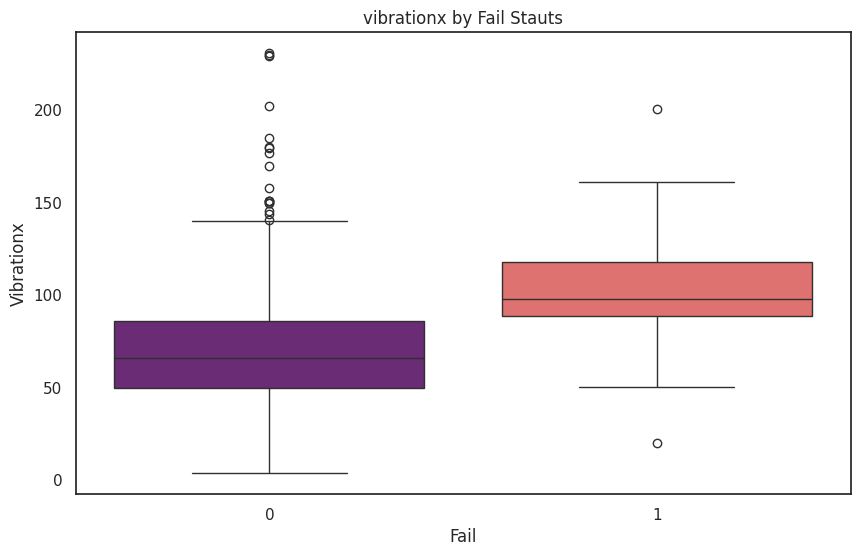



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



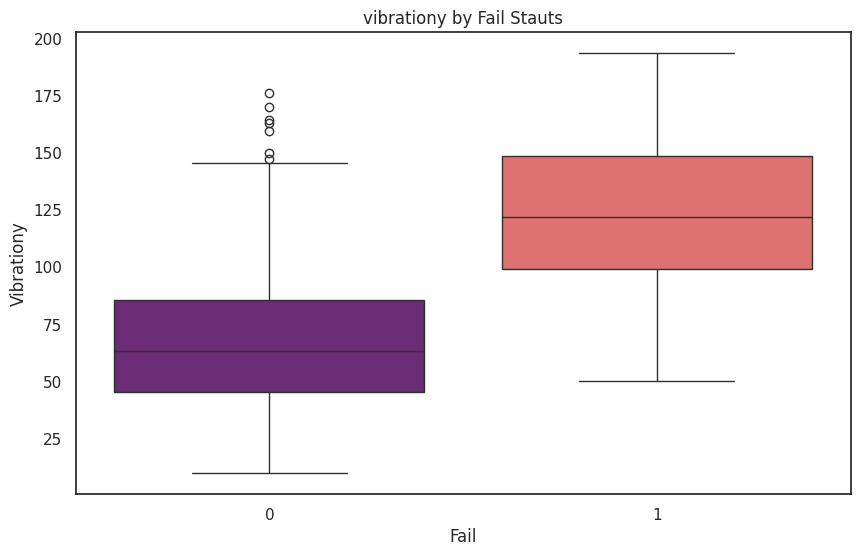



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



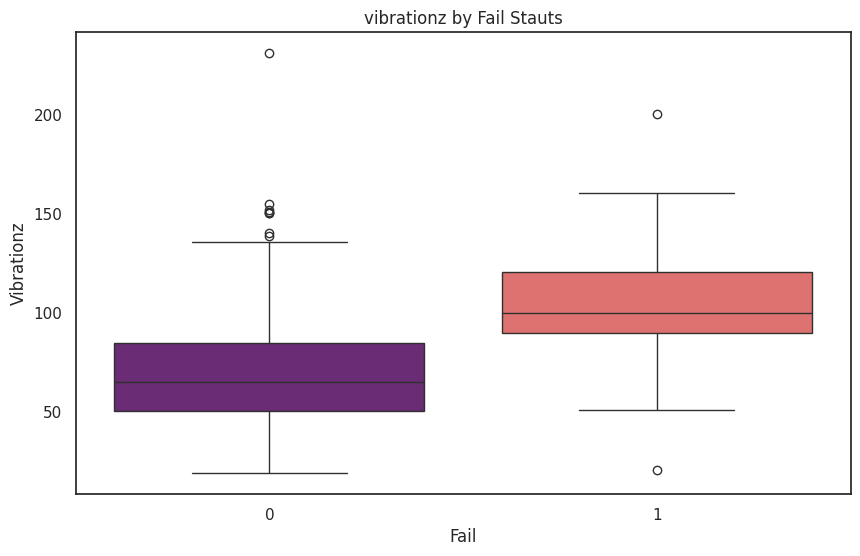

In [15]:
for var in numerical_cols:
    data_explorator.plot_box_plots_by_failure(df_transformed,var)

In [16]:
for i in numerical_cols:
    data_explorator.calculate_overall_and_before_variable_mean(df_transformed,i)


 Variable: temperature
          Mean  temperature
0      Overall    69.263496
1  Before Fail    94.017975

 Variable: pressure
          Mean    pressure
0      Overall   78.997940
1  Before Fail  114.088676

 Variable: vibrationx
          Mean  vibrationx
0      Overall   73.860275
1  Before Fail   99.214432

 Variable: vibrationy
          Mean  vibrationy
0      Overall   72.786880
1  Before Fail  117.857124

 Variable: vibrationz
          Mean  vibrationz
0      Overall   71.866211
1  Before Fail  105.964668


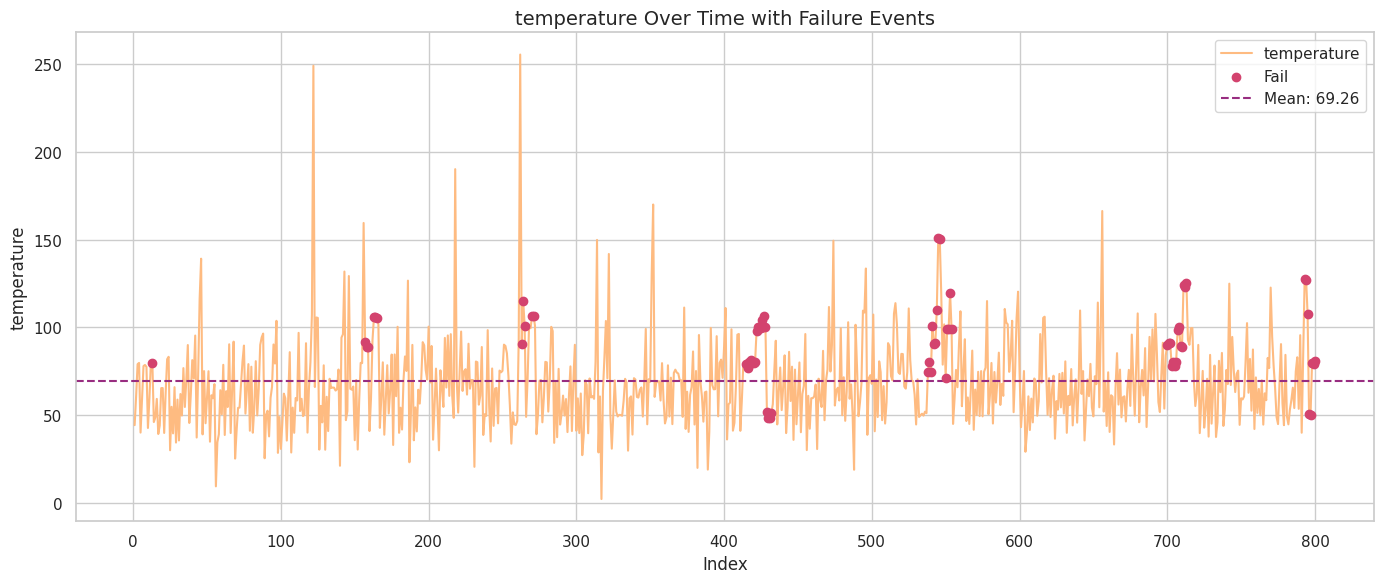

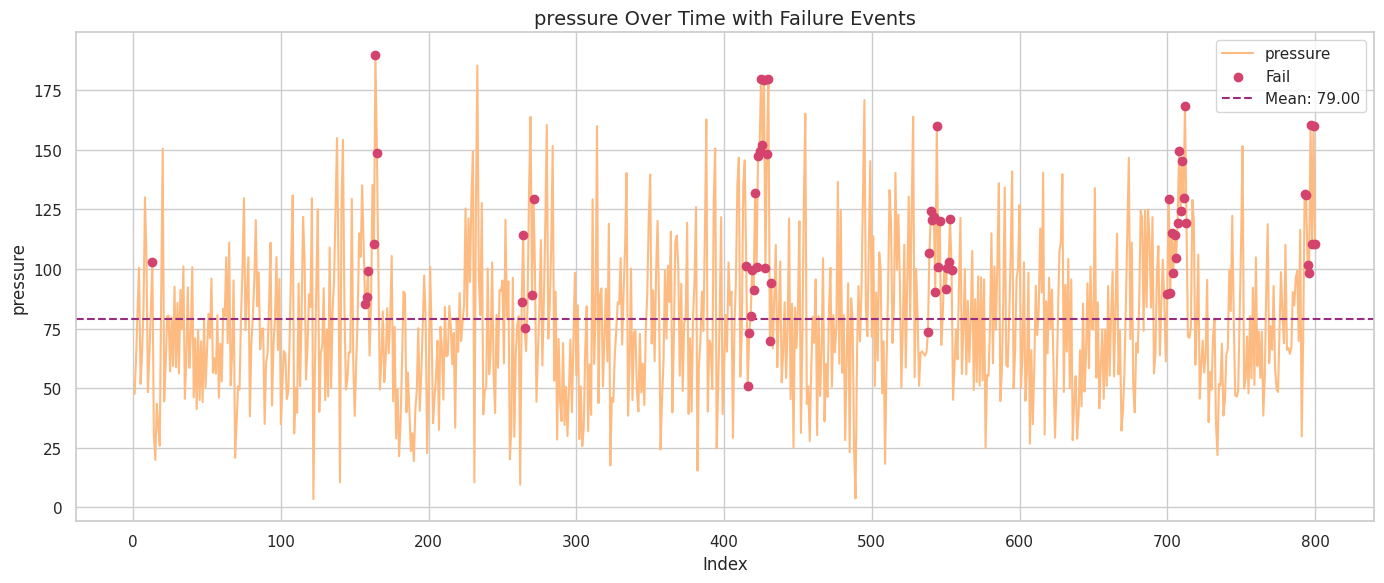

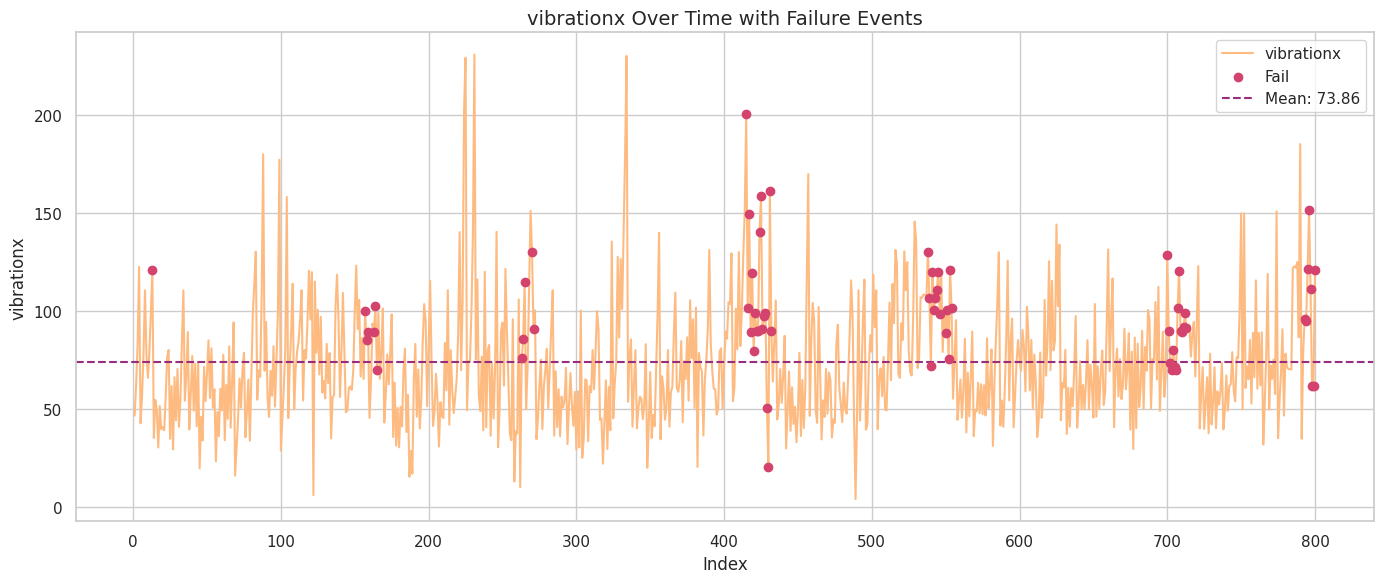

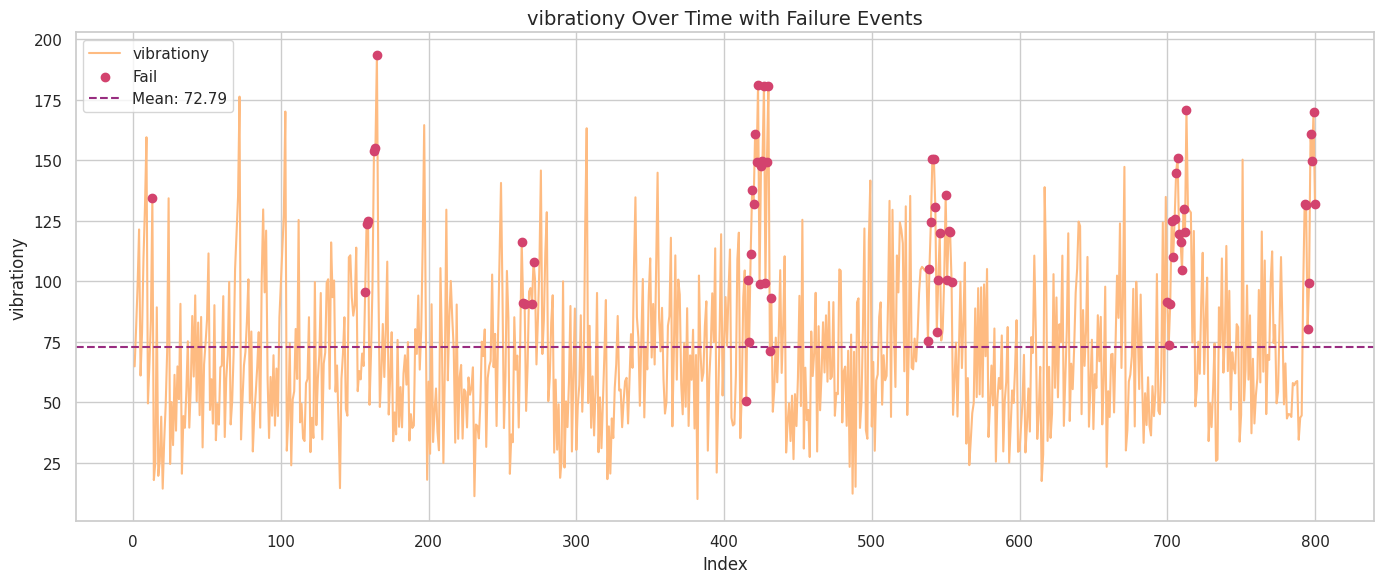

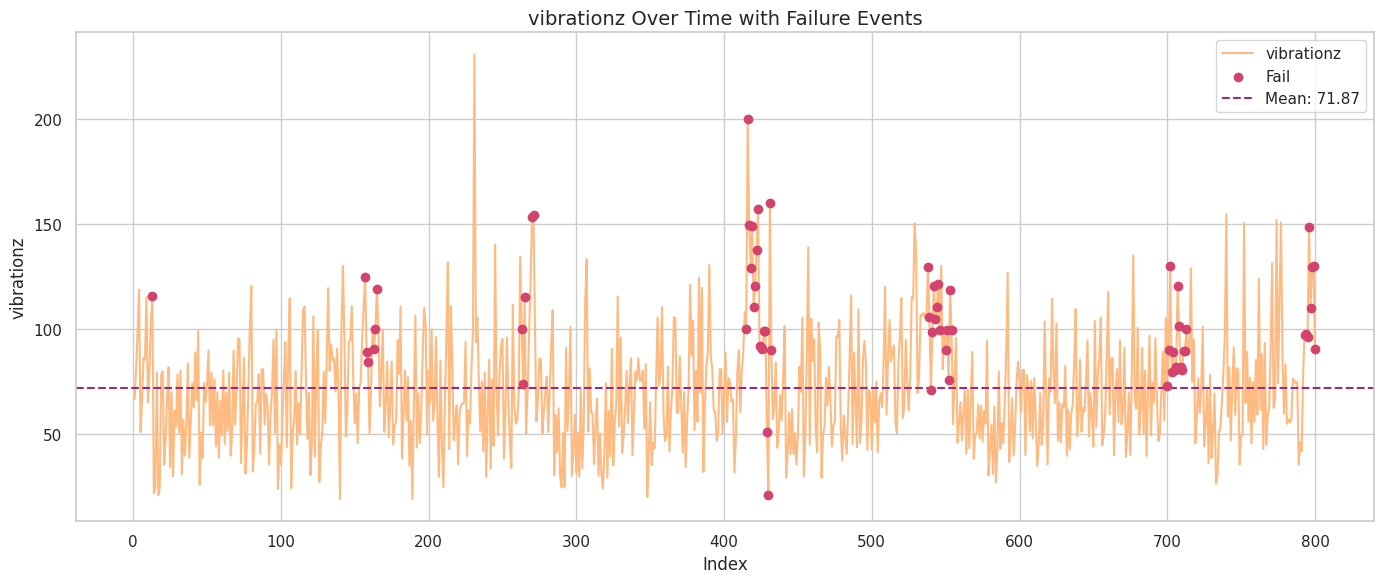

In [17]:
for var in numerical_cols:
    data_explorator.plot_variables_time_series_with_failures(df_transformed, var)

In [18]:
# for var in numerical_cols:
#     data_explorator.test_t_for_average(df_transformed,var)

In [19]:
for i in numerical_cols:
    threshold_results = data_explorator.find_thresholds(df_transformed, i)
    print(f"\n Variable: {i}")
    print(threshold_results.sort_values(by='delta_fail_rate', ascending=False).head())


 Variable: temperature
    threshold  fail_rate_above  fail_rate_below  delta_fail_rate  count_above
7   95.490899         0.270270         0.052250         0.218021          111
9  122.177055         0.291667         0.076031         0.215636           24
6   82.147821         0.218085         0.040850         0.177235          188
8  108.833977         0.243902         0.073781         0.170121           41
5   68.804743         0.161290         0.014019         0.147272          372

 Variable: pressure
     threshold  fail_rate_above  fail_rate_below  delta_fail_rate  count_above
19  189.995682         1.000000         0.081352         0.918648            1
17  170.362481         0.666667         0.078086         0.588581            6
18  180.179082         0.500000         0.081454         0.418546            2
16  160.545881         0.454545         0.077313         0.377232           11
14  140.912681         0.428571         0.066667         0.361905           35

 Variable: v

When analyzing the numeric variables, we observed moderate correlations between temperature and pressure, as well as between pressure and vibration X, and moderate correlations among all vibration axes with vibration Z. Most importantly, we identified a moderate correlation between vibration Y and the failure indicator.

Using boxplots and comparing the average values of each variable before failure versus overall averages, we found that all mean values increase during and before a failure. This suggests a consistent pattern of variable escalation leading up to failure events.

To further investigate, we calculate thresholds for each variable and analyzed how failure rates change above and below those cuts. 
    Temperature ≥ 95

    Pressure ≥ 160

    Vibration X ≥ 87

    Vibration Y ≥ 145

    Vibration Z ≥ 141

These thresholds can serve as early warning signs in monitoring systems to proactively detect and prevent equipment failure.

4. Create a model (or models) using the technique you think is most appropriate and measure its performance.

Based on the given time-series dataset, which models or techniques are suitable for predicting whether the equipment will fail before it occurs? Additionally, how can the model's performance be tuned and measured for this task?

In [20]:
df_transformed =  df_transformed.drop(columns=['preset_combined','fail_continued','fail_next'])
df_times_based, times_based_categorical_cols, times_based_numerical_cols  = preprocessing.create_time_based_columns(
                            df_transformed, numerical_cols, df_transformed.columns.tolist())

times_based_categorical_cols.remove(target)
# df_times_based = df_times_based.dropna(how='any').reset_index(drop=True)

In [21]:
df_times_based.head()

,preset_1,preset_2,temperature,pressure,vibrationx,vibrationy,vibrationz,frequency,fail,combo_lag1,temperature_rolling_5,pressure_rolling_5,vibrationx_rolling_5,vibrationy_rolling_5,vibrationz_rolling_5,preset_1_lag1,preset_2_lag1,temperature_lag1,pressure_lag1,vibrationx_lag1,vibrationy_lag1,vibrationz_lag1,frequency_lag1,fail_lag1,combo_lag1_lag1
0,2,5,39.989056,51.764832,42.514301,61.037910,50.716469,64.245166,0,2_3,60.755051,69.226997,71.193291,85.238098,83.171028,2,3,79.716240,100.508636,122.362320,121.363426,118.652534,80.315567,0.0,2_1
1,1,2,58.336086,64.426353,56.479225,78.623741,65.911530,78.886214,0,2_5,63.575230,72.580818,73.200783,87.998779,83.062424,2,5,39.989056,51.764832,42.514301,61.037910,50.716469,64.245166,0.0,2_3
2,1,3,77.937775,83.146660,77.800591,109.679047,86.230728,99.681179,0,1_2,67.001335,76.575737,76.359711,93.791702,84.059288,1,2,58.336086,64.426353,56.479225,78.623741,65.911530,78.886214,0.0,2_5
3,1,4,78.563507,130.089905,110.479874,130.997025,85.218559,98.467375,0,1_3,66.908531,85.987274,81.927261,100.340233,81.345963,1,3,77.937775,83.146660,77.800591,109.679047,86.230728,99.681179,0.0,1_2
4,3,7,77.486221,104.462952,77.390388,159.423477,115.211937,98.900268,0,1_4,66.462532,86.778137,72.932877,107.952240,80.657845,1,4,78.563507,130.089905,110.479874,130.997025,85.218559,98.467375,0.0,1_3


In [22]:
trainer = ModelTrainer(df_times_based, times_based_categorical_cols, times_based_numerical_cols, target)
random_search, X_test, y_test = trainer.train()

best_params = trainer.get_best_params(random_search)
best_score = trainer.get_best_score(random_search)    

print("Best parameters:", best_params)
print("Best score:", best_score)

y_pred = trainer.predict(random_search,X_test)
y_pred_proba = trainer.predict_proba(random_search,X_test)

Fitting 3 folds for each of 1 candidates, totalling 3 fits


The total space of parameters 1 is smaller than n_iter=10. Running 1 iterations. For exhaustive searches, use GridSearchCV.


[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=200, model__num_leaves=31; total time=  29.0s
[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=200, model__num_leaves=31; total time=  32.4s
[CV] END model__learning_rate=0.05, model__max_depth=6, model__n_estimators=200, model__num_leaves=31; total time=  32.3s
Best parameters: {'model__num_leaves': 31, 'model__n_estimators': 200, 'model__max_depth': 6, 'model__learning_rate': 0.05}
Best score: 0.9626102292768959


Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       217
           1       0.87      0.91      0.89        22

    accuracy                           0.98       239
   macro avg       0.93      0.95      0.94       239
weighted avg       0.98      0.98      0.98       239



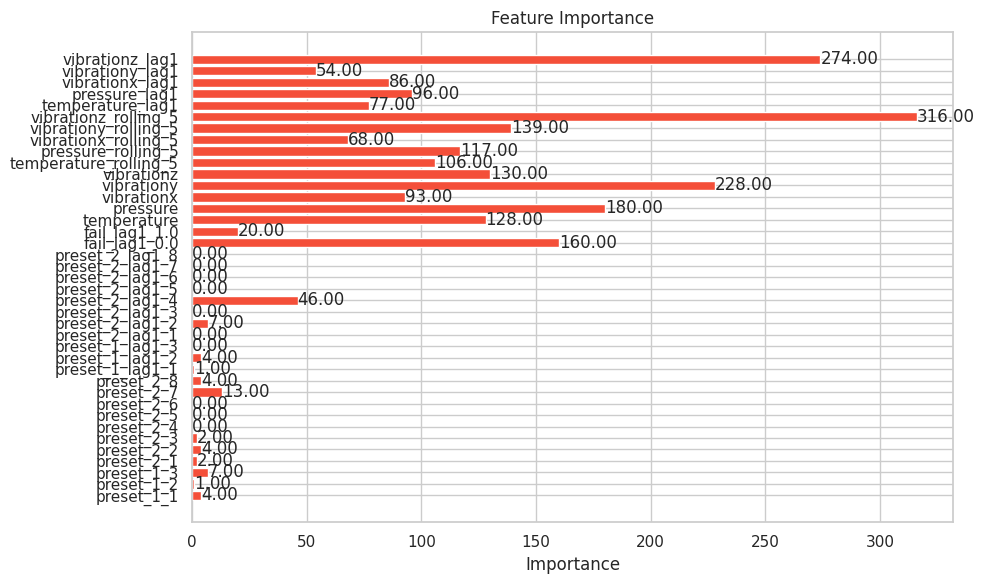

LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray


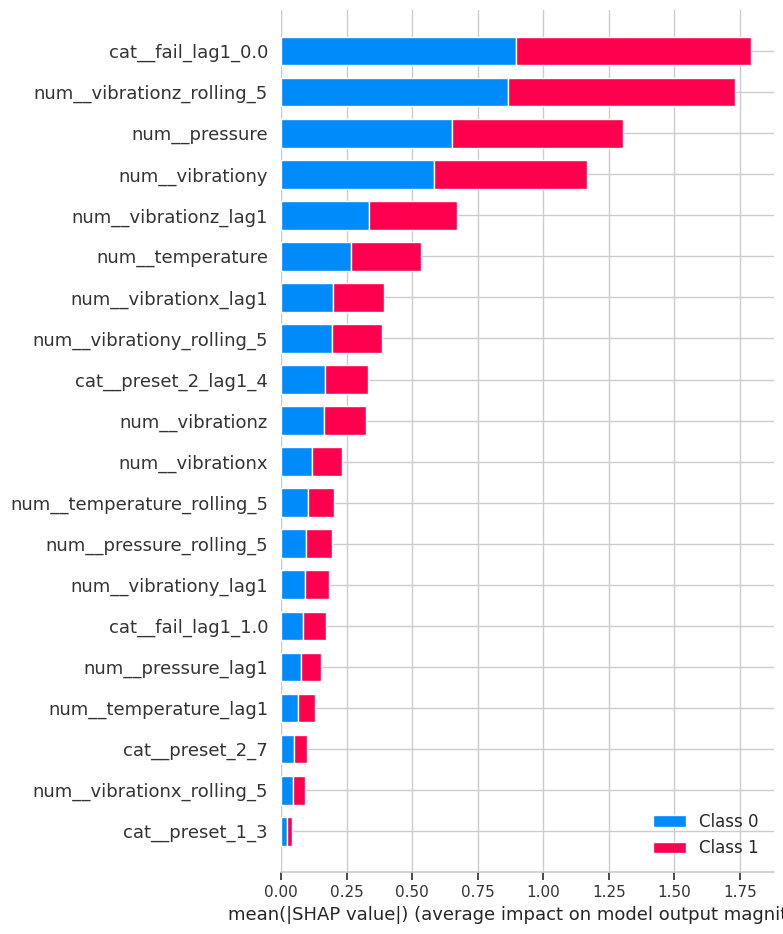

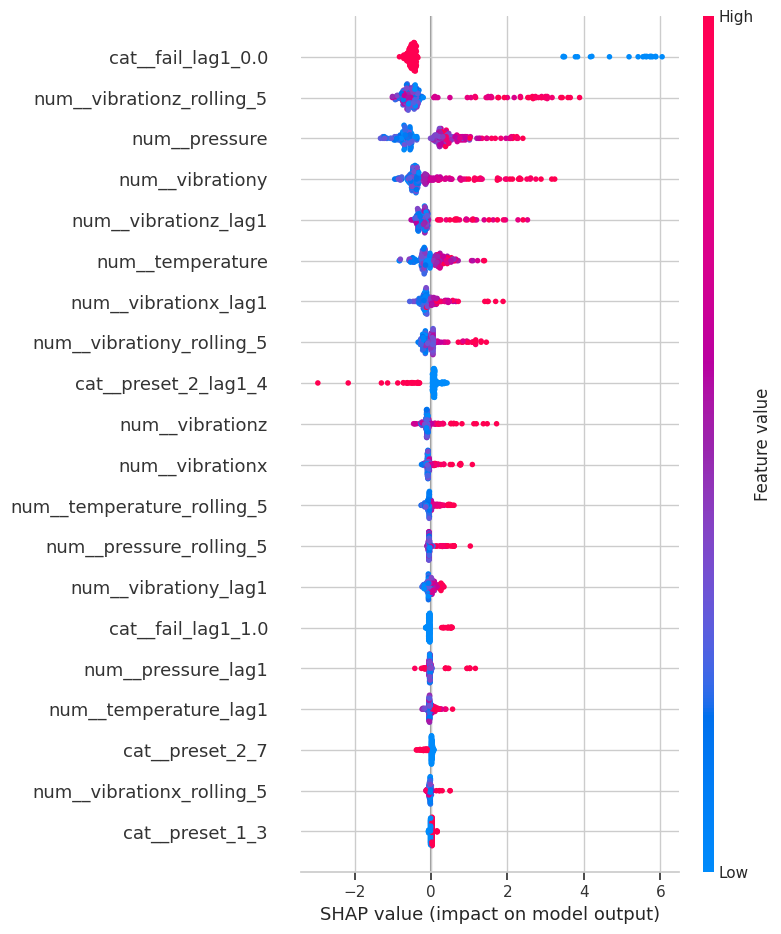

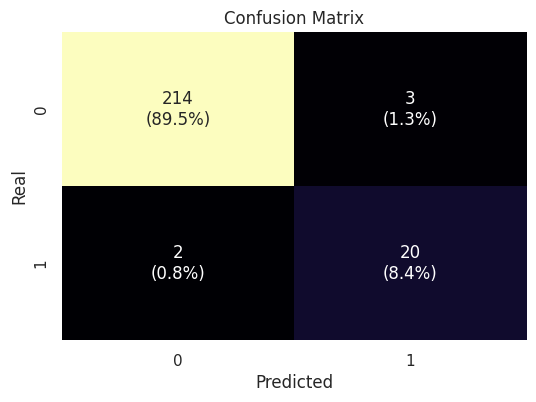

In [23]:
evaluator = ModelEvaluator(y_pred,y_pred_proba,y_test,X_test,random_search,times_based_categorical_cols,times_based_numerical_cols)
evaluator.evaluate()